# Phase 2 — Exploratory Data Analysis
**Project:** Biological Age Predictor  
**Data:** NHANES August 2021–August 2023 (8 merged survey tables)  
**Dataset:** `data/processed/merged_data.csv` — 6,337 participants × 128 features

This notebook performs exploratory data analysis (EDA) across four areas: univariate distributions, correlation structure, subgroup comparisons, and a final written synthesis of key findings.

---

## Setup

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Add src/ to path so we can import our reusable utilities
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root / 'src'))
from eda_utils import plot_biomarker_distributions, biomarker_summary_table

# Load the merged dataset
df = pd.read_csv(project_root / 'data' / 'processed' / 'merged_data.csv')
print(f'Dataset shape: {df.shape}')
df.head(3)

Dataset shape: (6337, 128)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,LBXPLTSI,LBXMPSI,LBXNRBC,PAD790Q,PAD790U,PAD800,PAD810Q,PAD810U,PAD820,PAD680
0,130378.0,12.0,2.0,1.0,43.0,NaN,5.0,6.0,2.0,NaN,...,259.0,7.8,0.3,3.0,W,45.0,3.0,W,45.0,360.0
1,130379.0,12.0,2.0,1.0,66.0,NaN,3.0,3.0,2.0,NaN,...,221.0,8.5,0.1,4.0,W,45.0,3.0,W,45.0,480.0
2,130380.0,12.0,2.0,2.0,44.0,NaN,2.0,2.0,1.0,NaN,...,235.0,9.1,0.1,1.0,W,20.0,0.0,NaN,NaN,240.0


---

## 2.1 — Univariate Exploration

### Why This Matters for This Project

Before building a model to predict biological age, we need to understand the **shape and quality** of every input variable. This matters here for three specific downstream reasons:

1. **Log-transforming skewed biomarkers (Phase 3):** A regression model assumes roughly symmetric errors. Biomarkers like fasting glucose, triglycerides, and creatinine are right-skewed — extreme values in the right tail will pull the model's predictions toward those outliers and produce misleading SHAP values in Phase 5. We identify skew here so we can log-transform those features in Phase 3.

2. **Missingness strategy (Phase 3):** Several lab-based biomarkers have ~10% missingness because NHANES only draws fasting blood from a subsample. We need to decide now — drop rows, impute with median, or flag as a separate binary feature. A biomarker with >15% missing is probably not worth including at all.

3. **Outlier detection (Phase 3 + Phase 5):** Implausible extreme values (e.g., a creatinine of 40 mg/dL) are not biologically real — they are measurement errors or data entry artefacts. If left in, they will dominate SHAP explanations and make the model untrustworthy.

---

### Column Dictionary

NHANES uses cryptic column codes. Here is the mapping for the key biomarkers we'll work with throughout this project.

In [2]:
# Human-readable labels for all key biomarkers
BIOMARKER_LABELS = {
    # --- Demographics & anthropometry ---
    'RIDAGEYR'  : 'Age (years)',
    'RIAGENDR'  : 'Sex (1=Male, 2=Female)',
    'BMXBMI'    : 'BMI (kg/m²)',
    'BMXWT'     : 'Weight (kg)',
    'BMXHT'     : 'Height (cm)',
    'BMXWAIST'  : 'Waist Circumference (cm)',
    # --- Metabolic ---
    'LBXSGL'    : 'Fasting Glucose (mg/dL)',
    'LBXGH'     : 'HbA1c (%)',
    'LBXTC'     : 'Total Cholesterol (mg/dL)',
    'LBXSTR'    : 'Triglycerides (mg/dL)',
    # --- Kidney & liver ---
    'LBXSCR'    : 'Creatinine (mg/dL)',
    'LBXSUA'    : 'Uric Acid (mg/dL)',
    'LBXSCA'    : 'Calcium (mg/dL)',
    'LBXSATSI'  : 'ALT – Liver Enzyme (U/L)',
    'LBXSGTSI'  : 'GGT – Liver Enzyme (U/L)',
    # --- Complete Blood Count ---
    'LBXWBCSI'  : 'WBC Count (×10³/µL)',
    'LBXRBCSI'  : 'RBC Count (×10⁶/µL)',
    'LBXHGB'    : 'Hemoglobin (g/dL)',
    'LBXHCT'    : 'Hematocrit (%)',
    'LBXPLTSI'  : 'Platelets (×10³/µL)',
    'LBXMCVSI'  : 'Mean Corpuscular Volume (fL)',
    # --- Lifestyle ---
    'SMQ020'    : 'Ever Smoked (1=Yes, 2=No)',
    'PAD680'    : 'Sedentary Time (min/day)',
}

# The columns we'll use (numeric biomarkers only, excluding categorical sex/smoking)
NUMERIC_BIOMARKERS = [
    'RIDAGEYR', 'BMXBMI', 'BMXWT', 'BMXHT', 'BMXWAIST',
    'LBXSGL', 'LBXGH', 'LBXTC', 'LBXSTR',
    'LBXSCR', 'LBXSUA', 'LBXSCA', 'LBXSATSI', 'LBXSGTSI',
    'LBXWBCSI', 'LBXRBCSI', 'LBXHGB', 'LBXHCT', 'LBXPLTSI', 'LBXMCVSI',
    'PAD680',
]
print(f'Plotting {len(NUMERIC_BIOMARKERS)} biomarkers')

Plotting 21 biomarkers


---

### 2.1.1 — Summary Statistics Table

This table gives us a **data quality snapshot** before we look at any charts. Pay attention to the `⚠ Flag` column — any row marked *Log-transform* has a skewness > 3, meaning its distribution is so right-tailed that it needs to be transformed before modeling.

In [3]:
summary = biomarker_summary_table(df, NUMERIC_BIOMARKERS, labels=BIOMARKER_LABELS)
summary

,Label,N (non-null),Missing %,Mean,Median,Std,Min,Max,Skew,⚠ Flag
Column,,,,,,,,,,
RIDAGEYR,Age (years),6337,0.0%,52.3,56,18.3,18,80,-0.28,
BMXBMI,BMI (kg/m²),6235,1.6%,29.7,28.3,7.4,11.1,74.8,1.20,
BMXWT,Weight (kg),6248,1.4%,82.9,79.5,22.5,27.9,248,1.10,
BMXHT,Height (cm),6262,1.2%,167,167,10.1,133,201,0.13,
BMXWAIST,Waist Circumference (cm),6019,5.0%,100,99,17.2,59.6,187,0.57,
LBXSGL,Fasting Glucose (mg/dL),5688,10.2%,104,95,38,40,898,6.27,Log-transform
LBXGH,HbA1c (%),6002,5.3%,5.76,5.5,1.1,3.2,17.1,3.72,Log-transform
LBXTC,Total Cholesterol (mg/dL),5717,9.8%,187,184,42.7,62,438,0.57,
LBXSTR,Triglycerides (mg/dL),5689,10.2%,133,108,95.5,24,1.72e+03,4.45,Log-transform


---

### 2.1.2 — Distribution Plots: Anthropometry & Metabolic Markers

Each subplot shows a **histogram + KDE** (smoothed density curve) with an annotation box reporting the median, skewness, and % missing.

**What to look for:**
- A title prefixed with ⚠ signals skewness > 3 — a red flag for log-transformation.
- A long right tail (most values bunched left, but a few extreme values far right) indicates right skew.
- Bimodal distributions (two humps) may indicate a subpopulation effect — for example, age distributions that reflect the NHANES sampling design.

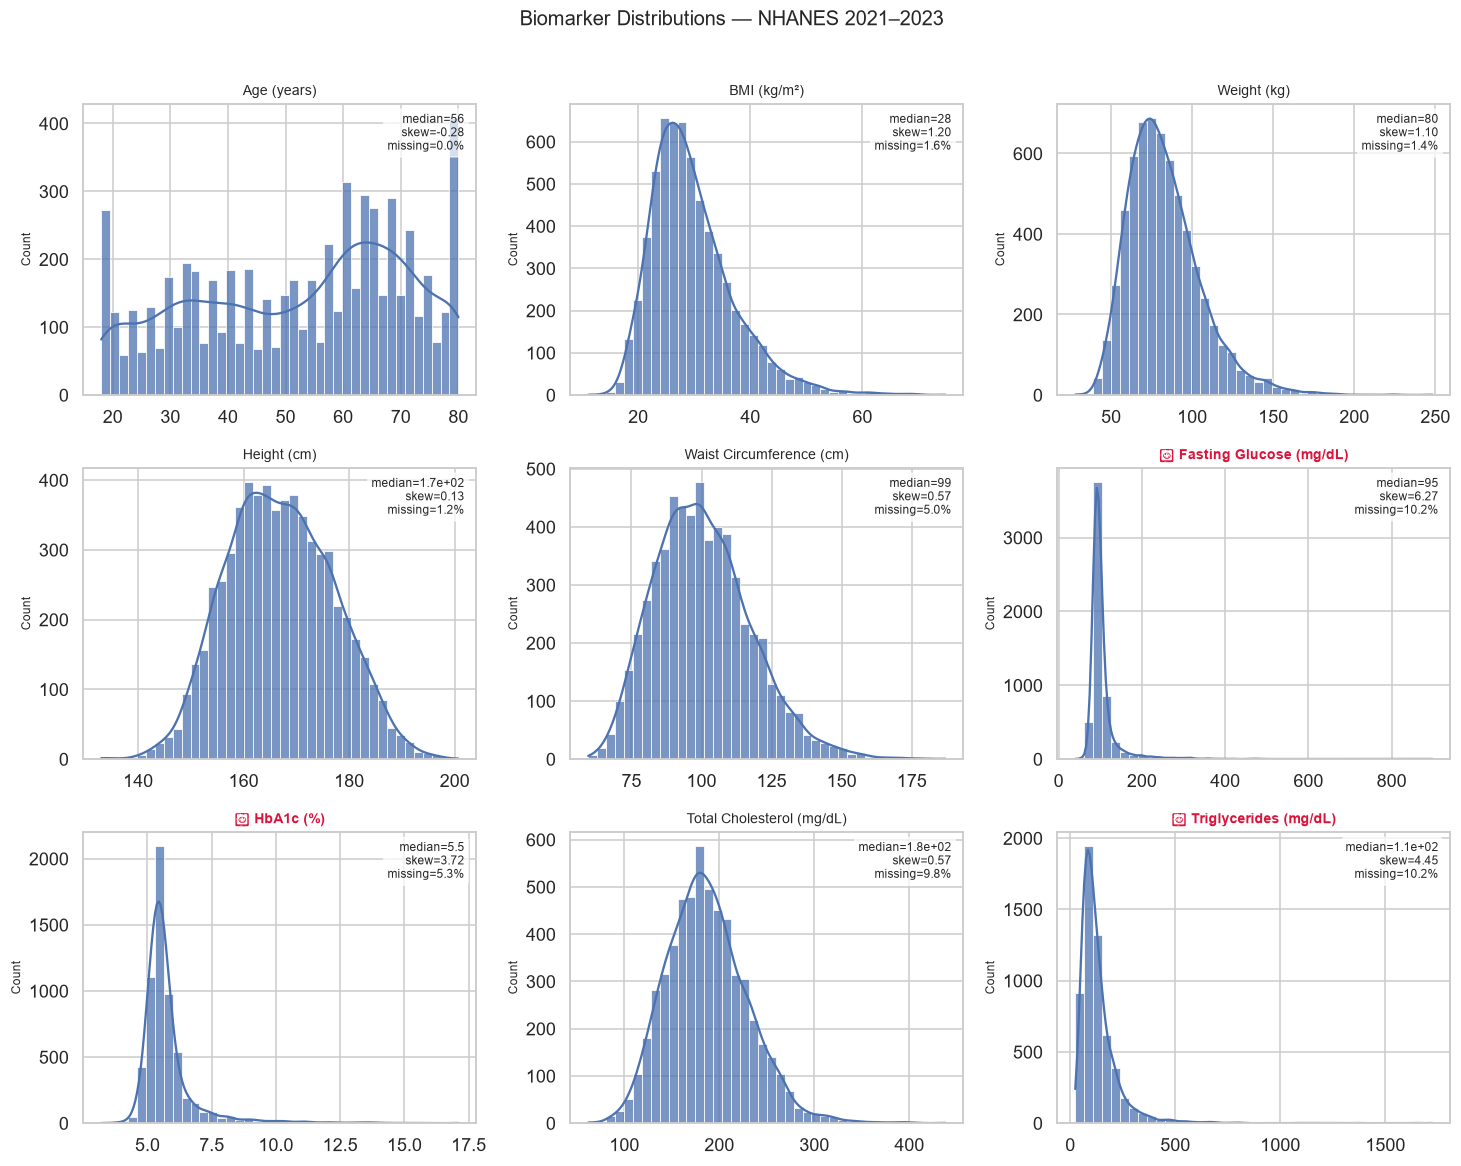

In [4]:
ANTHRO_METABOLIC = [
    'RIDAGEYR', 'BMXBMI', 'BMXWT', 'BMXHT', 'BMXWAIST',
    'LBXSGL', 'LBXGH', 'LBXTC', 'LBXSTR',
]

plot_biomarker_distributions(
    df, ANTHRO_METABOLIC, labels=BIOMARKER_LABELS, n_cols=3
)

**🔍 Red Flags to Note:**
- **Fasting Glucose (LBXSGL)** — skew ~6.3: A long right tail driven by diabetic participants. This column will need **log-transformation** in Phase 3. Also has 10.2% missing (fasting subsample only).
- **Triglycerides (LBXSTR)** — skew ~4.4: Similarly right-skewed due to hypertriglyceridemic participants. Log-transform required.
- **HbA1c (LBXGH)** — skew ~3.7: Moderate right skew from diabetic participants. Worth log-transforming.
- **BMI (BMXBMI)** — skew ~1.2: Moderate skew, borderline — inspect further during feature engineering.

---

### 2.1.3 — Distribution Plots: Kidney, Liver & Blood Count Markers

These are the laboratory markers from the Biochemistry (`BIOPRO_L`) and Complete Blood Count (`CBC_L`) tables. Many of these will be strong predictors of biological age — but some are highly skewed or have high missingness.

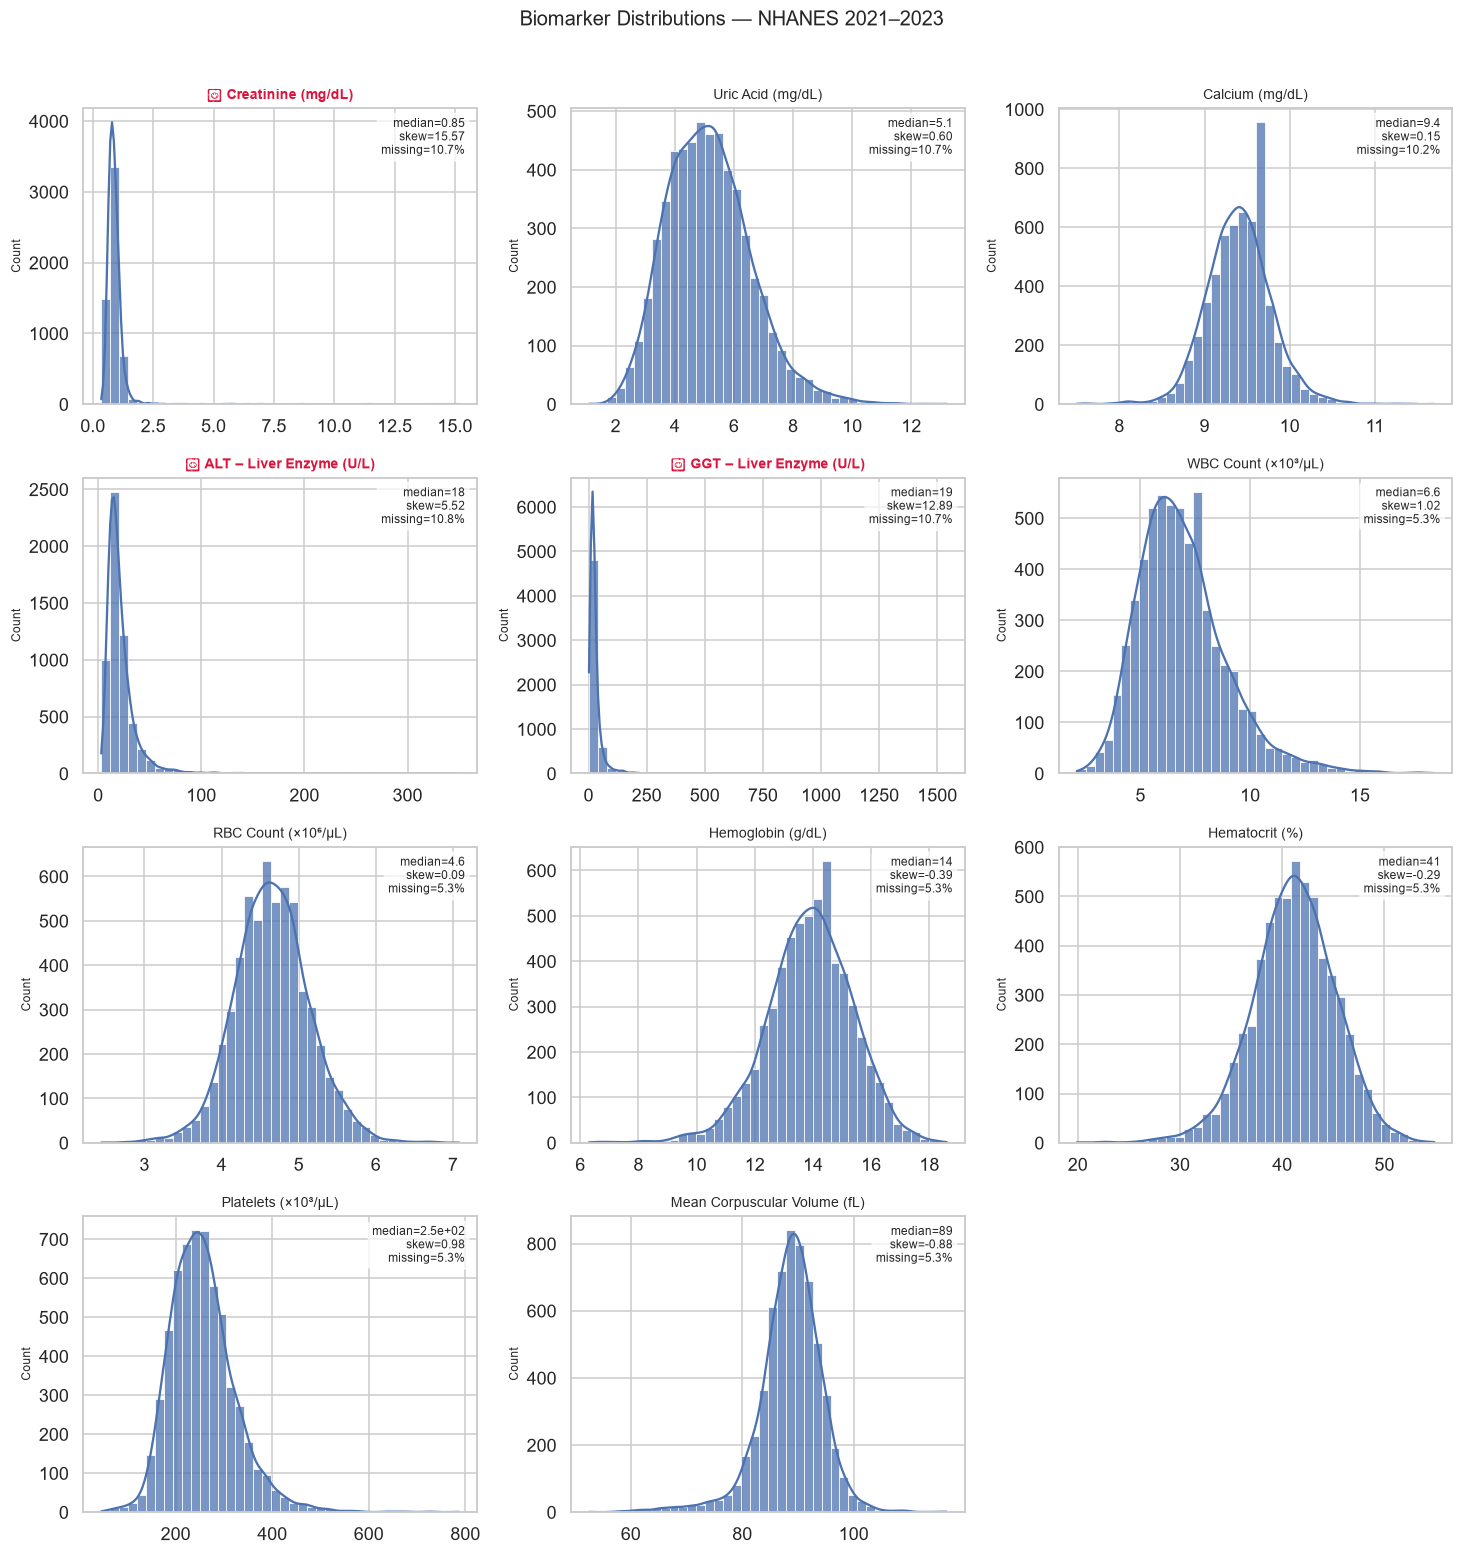

In [5]:
KIDNEY_CBC = [
    'LBXSCR', 'LBXSUA', 'LBXSCA', 'LBXSATSI', 'LBXSGTSI',
    'LBXWBCSI', 'LBXRBCSI', 'LBXHGB', 'LBXHCT', 'LBXPLTSI', 'LBXMCVSI',
]

plot_biomarker_distributions(
    df, KIDNEY_CBC, labels=BIOMARKER_LABELS, n_cols=3
)

**🔍 Red Flags to Note:**
- **Creatinine (LBXSCR)** — skew ~15.6: Extreme right skew. This is the most important one to watch — a small number of participants with severe kidney disease drive the tail to extreme values. **Log-transform is essential.** Also has 10.7% missing.
- **ALT (LBXSATSI) & GGT (LBXSGTSI)** — liver enzymes: Both tend to be right-skewed in population data due to participants with liver disease or heavy alcohol use. Check the skew values from the table above.
- **WBC Count (LBXWBCSI)** — skew ~1.0: Mild right skew, acceptable but worth monitoring.
- **MCV (LBXMCVSI)** — skew ~-0.9: Slight left skew, roughly symmetric — no transformation needed.

---

### 2.1.4 — Distribution: Sedentary Time (Lifestyle Marker)

Sedentary time (`PAD680`) is the only continuous lifestyle marker from the Physical Activity questionnaire. It captures daily minutes spent sitting/reclining. It is worth inspecting separately because lifestyle factors are expected to have strong **SHAP contributions** in Phase 5.

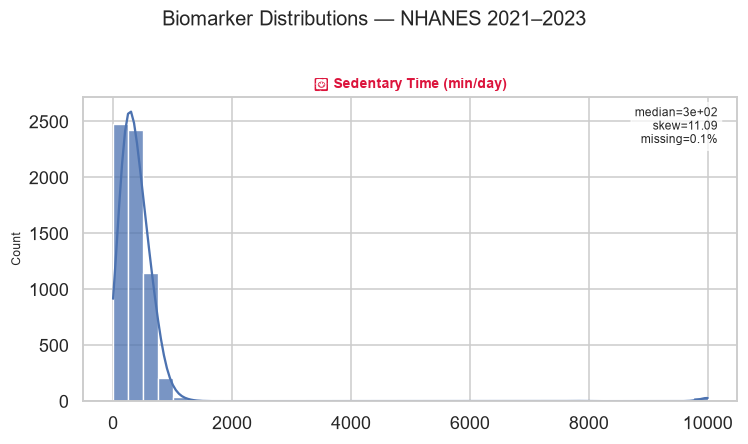

In [6]:
plot_biomarker_distributions(
    df, ['PAD680'], labels=BIOMARKER_LABELS, n_cols=1, figsize_per_plot=(7, 4)
)

**🔍 Red Flag:**
- **Sedentary Time (PAD680)** — skew ~11.1: Extremely right-skewed. Many respondents report values in the normal range (300–600 min/day ≈ 5–10 hours), but a small number report implausibly high values (> 1,000 min/day = more than 16 hours of sitting). These extreme values are likely rounding artefacts in the survey. **This column will need log-transformation and/or capping at a sensible upper bound (e.g., 95th percentile) in Phase 3.**

---

### 2.1.5 — Age Distribution (Our Target Variable)

Since our **target variable is chronological age (`RIDAGEYR`)**, its distribution directly determines what age ranges the model will be able to predict reliably. A model trained on a dataset where 80% of participants are aged 20–50 will make poor predictions for elderly participants.

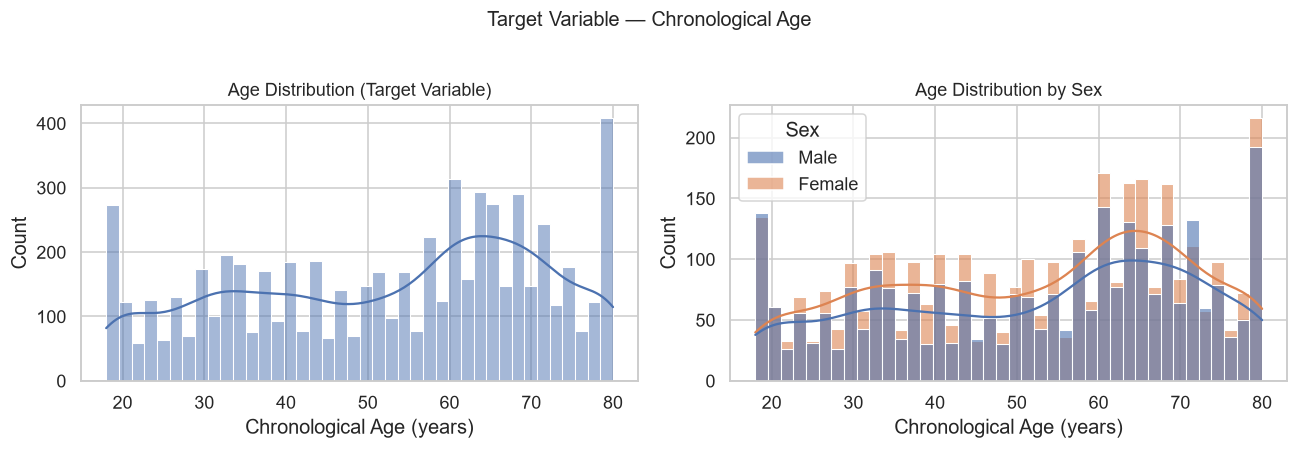

Age range: 18 – 80 years
Mean age: 52.3 | Median: 56


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of age
sns.histplot(df['RIDAGEYR'].dropna(), bins=40, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Age Distribution (Target Variable)', fontsize=12)
axes[0].set_xlabel('Chronological Age (years)')
axes[0].set_ylabel('Count')

# Age by sex
sex_map = {1.0: 'Male', 2.0: 'Female'}
df['Sex'] = df['RIAGENDR'].map(sex_map)
sns.histplot(
    data=df.dropna(subset=['RIDAGEYR', 'Sex']),
    x='RIDAGEYR', hue='Sex', bins=40, kde=True,
    ax=axes[1], palette={'Male': '#4C72B0', 'Female': '#DD8452'}, alpha=0.6
)
axes[1].set_title('Age Distribution by Sex', fontsize=12)
axes[1].set_xlabel('Chronological Age (years)')
axes[1].set_ylabel('Count')

plt.suptitle('Target Variable — Chronological Age', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Age range: {df['RIDAGEYR'].min():.0f} – {df['RIDAGEYR'].max():.0f} years")
print(f"Mean age: {df['RIDAGEYR'].mean():.1f} | Median: {df['RIDAGEYR'].median():.0f}")

**What to look for:**
- Is the distribution roughly uniform across age groups, or is one age band overrepresented?
- NHANES caps age reporting at 80 years (`RIDAGEYR` = 80 means 80+). This creates an artificial spike at 80 that will bias the model — we may want to restrict our analysis to participants aged < 80, or flag the 80+ group separately in Phase 3.
- Male vs. female distributions should be roughly similar — any large asymmetry might suggest sampling differences.

---

### 2.1 — Univariate Summary

The distributions above reveal three categories of variables:

| Category | Biomarkers | Observation |
|:---|:---|:---|
| **Heavily right-skewed (|skew| > 3)** | Creatinine, Fasting Glucose, Triglycerides, HbA1c, Sedentary Time | Long tails driven by disease subpopulations or rounding artefacts; log-transformation required before modeling. |
| **Moderately skewed (1 < |skew| < 3)** | BMI, Weight, WBC, Platelets | Acceptable for most models but should be monitored during feature engineering. |
| **Approximately symmetric** | Age, Height, Hemoglobin, Hematocrit, RBC, MCV, Calcium | Can be used as-is with standard scaling. |

**Missingness note:** Lab-based biomarkers (glucose, creatinine, cholesterol, HbA1c) each have ~10% missing values due to NHANES fasting subsample design. This is not random noise — it reflects a planned survey structure and will need deliberate imputation or indicator-variable treatment in preprocessing.